**Author: Atanazy Gawrysiak**

Import libraries:

In [ ]:
!pip install kmodes
!pip install gower

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import gower
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from scipy.stats import lognorm, expon

## Task 1. Data description

### Loading data

Loading data and dropping "id" column

In [ ]:
# Dataset from friend's github repo, so there is not need to manually upload it
!curl -LO https://raw.githubusercontent.com/Empajerek/WUMdataset/refs/heads/main/earnings.csv
df_raw = pd.read_csv('earnings.csv', header=None)
header = [col.strip('"') for col in df_raw.iloc[0, 0].split(";")]
data = df_raw.iloc[1:, 0].str.split(";", expand=True)
data.columns = header
data.reset_index(drop=True, inplace=True)
data = data.drop('id', axis=1)
data.head()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  652k  100  652k    0     0  1250k      0 --:--:-- --:--:-- --:--:-- 1251k


,base,bonus,overtime_pay,other,sector,section_07,sex,education,contract,age,duration_total,duration_entity,duration_nominal,duration_overtime
0,26651.53,0,0,0,1,3,2,4,1,49,33.03,7.06,1524.15,0
1,40168.5,1500,0,3414.32,1,2,1,1,1,36,10.07,6.01,1562.4,0
2,20134.8,0,0,1700.41,1,2,2,4,1,52,28.08,19.05,1816,0
3,16475,0,0,1305,1,2,2,5,1,55,35.07,11.01,1816,0
4,34797.6,0,1893.35,3118.73,1,2,2,2,1,50,27,19.01,722.8,63


In [ ]:
data.shape

(11000, 14)

As we can see there are 11000 observations in the sample.
There are 14 features - 5 categorical (quantitative) and 9 numerical (qualitative)

In [ ]:
numerical_columns = ["base", "bonus", "overtime_pay", "other", "age", "duration_total", "duration_entity", "duration_nominal", "duration_overtime"]
categorical_columns = ["sector", "section_07", "sex", "education", "contract"]

In [ ]:
for col in categorical_columns:
  print(f"{col}: {data[col].unique()}")

sector: ['1' '2']
section_07: ['3' '2' '1']
sex: ['2' '1']
education: ['4' '1' '5' '2' '3' '6']
contract: ['1' '2']


In [ ]:
for col in numerical_columns:
  data[col] = pd.to_numeric(data[col], errors='coerce')
data.isna().any()

,0
base,False
bonus,False
overtime_pay,False
other,False
sector,False
section_07,False
sex,False
education,False
contract,False
age,False


Apparently there is no missing data

In [ ]:
data.dtypes

,0
base,float64
bonus,float64
overtime_pay,float64
other,float64
sector,object
section_07,object
sex,object
education,object
contract,object
age,int64


### Describing variables

For categorical data I print frequency tables and plot it for readability

sector
1    10548
2      452
Name: count, dtype: int64



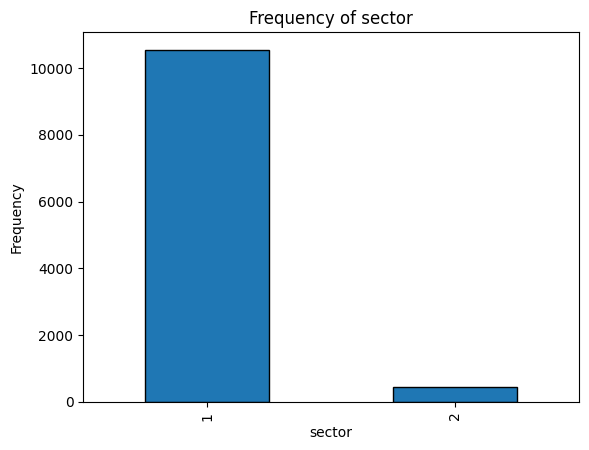

section_07
2    5867
3    2732
1    2401
Name: count, dtype: int64



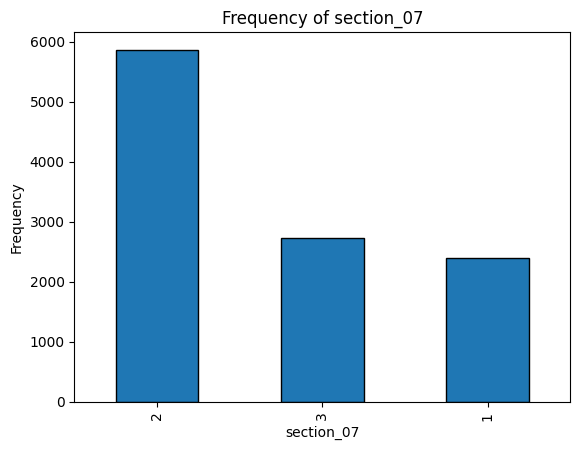

sex
2    8289
1    2711
Name: count, dtype: int64



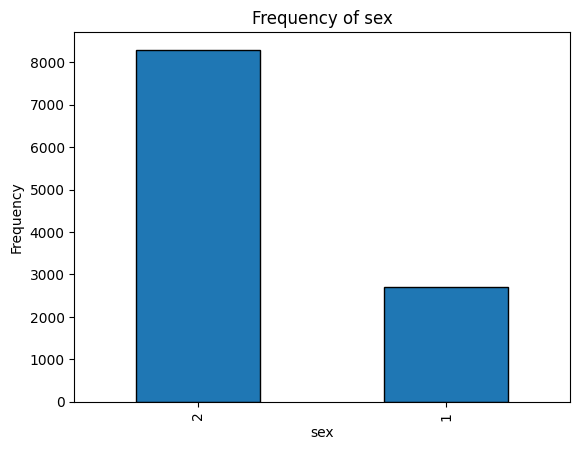

education
2    6633
4    1983
5     906
3     680
1     430
6     368
Name: count, dtype: int64



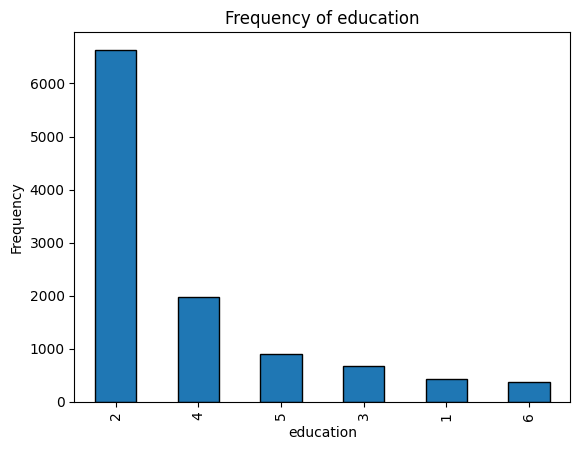

contract
1    9306
2    1694
Name: count, dtype: int64



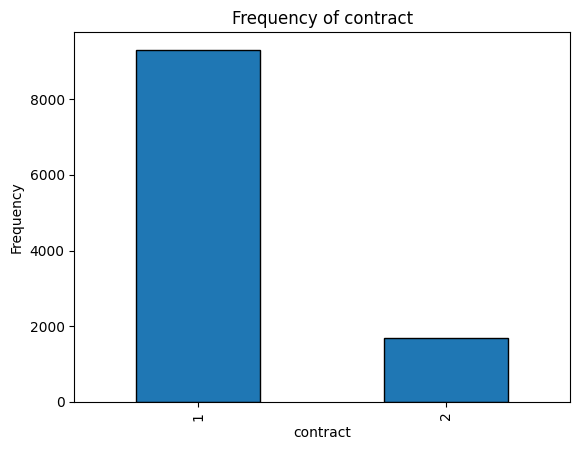

In [ ]:
for col in categorical_columns:
  frequency_table = data[col].value_counts()
  print(f"{frequency_table}\n")
  frequency_table.plot(kind='bar', edgecolor='black', title=f'Frequency of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()

And for numerical I print basic statistics

In [ ]:
for col in numerical_columns:
  print(f"{col}:\n{data[col].describe()}\n")

base:
count     11000.000000
mean      33376.738065
std       19276.551638
min          10.000000
25%       20995.115000
50%       31341.245000
75%       41348.290000
max      241624.390000
Name: base, dtype: float64

bonus:
count     11000.000000
mean       2128.486176
std        4966.444726
min           0.000000
25%           0.000000
50%         620.000000
75%        2940.717500
max      258061.000000
Name: bonus, dtype: float64

overtime_pay:
count     11000.000000
mean       1679.273923
std        5407.964344
min           0.000000
25%           0.000000
50%           0.000000
75%        1139.330000
max      228110.340000
Name: overtime_pay, dtype: float64

other:
count    11000.000000
mean      2477.625815
std       3715.419120
min          0.000000
25%          0.000000
50%       2141.820000
75%       3497.430000
max      88555.760000
Name: other, dtype: float64

age:
count    11000.000000
mean        42.470182
std         10.012140
min         19.000000
25%         34.000000
5

### Variables’ distributions

For numerical variables I plot distributions and compare them with normal and exponential distributions

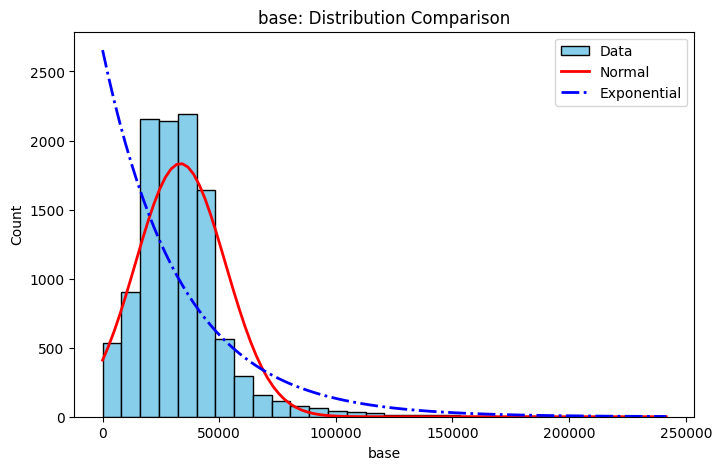

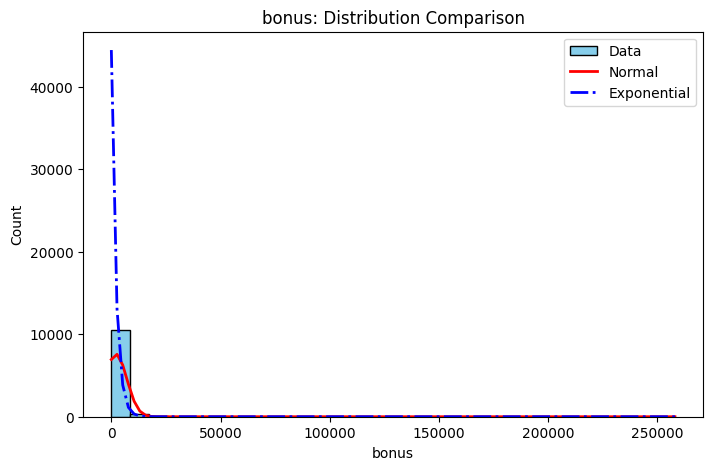

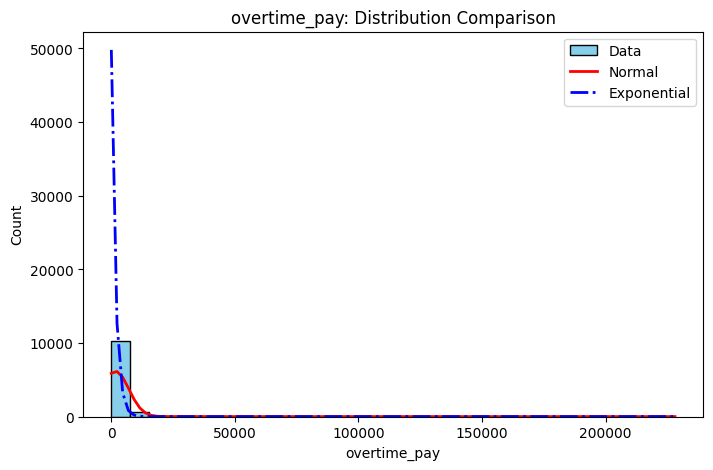

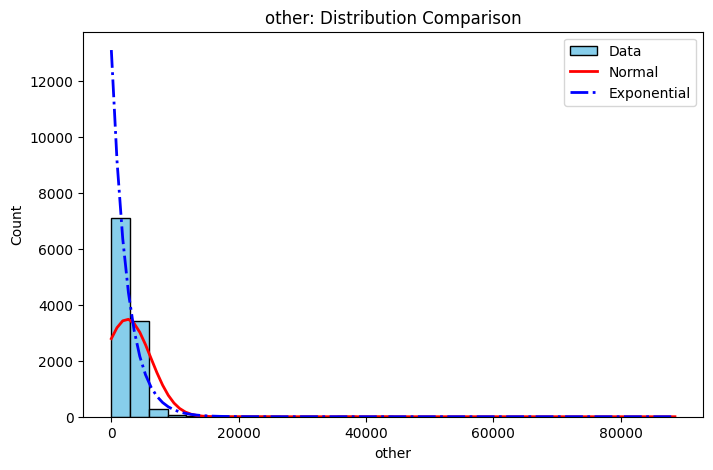

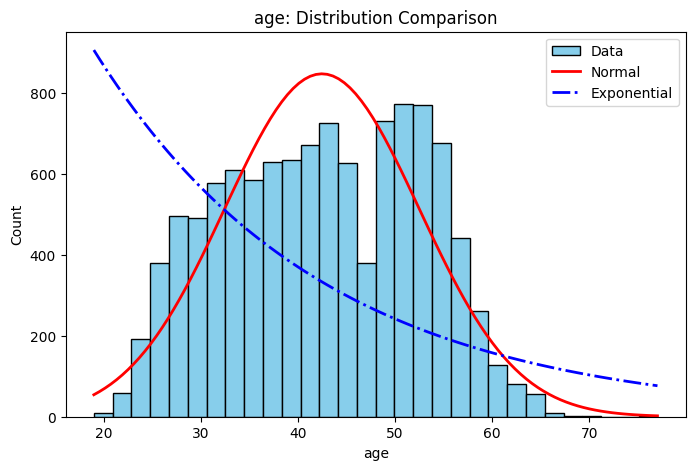

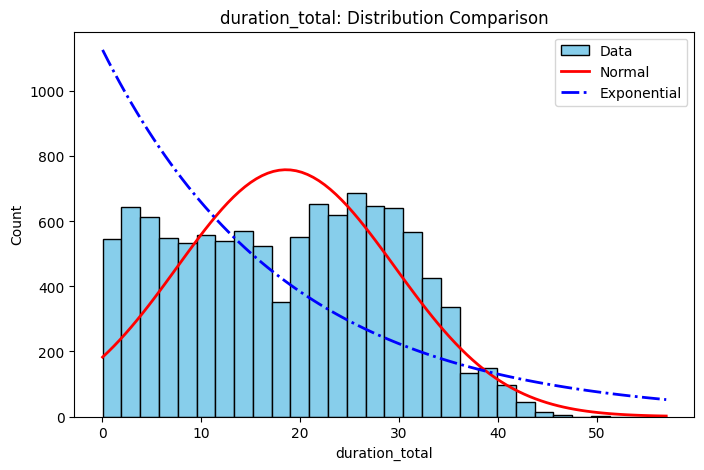

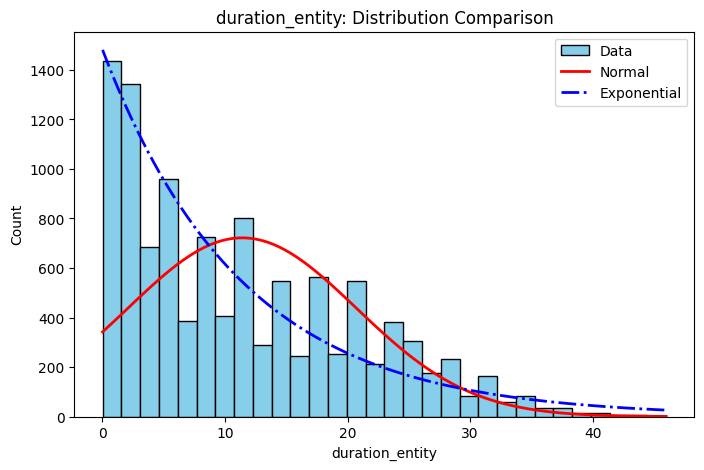

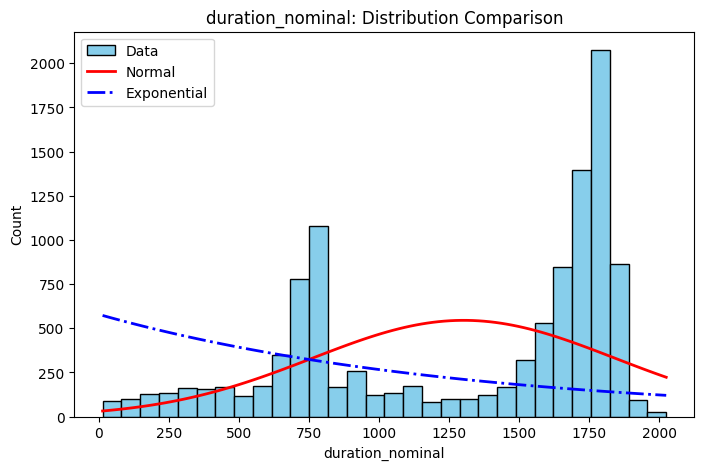

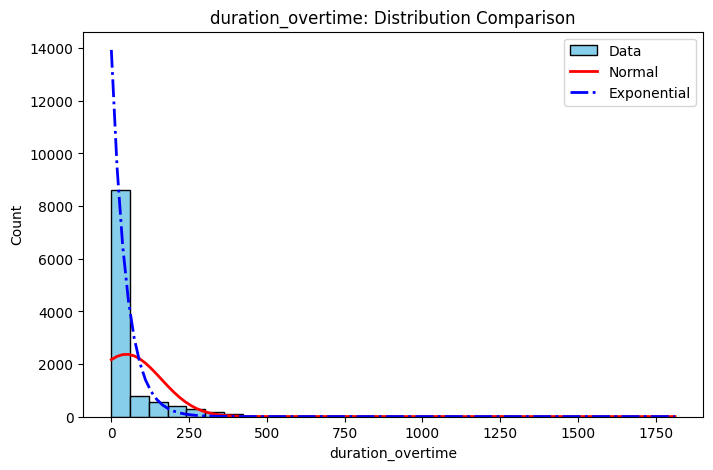

In [ ]:
for col in numerical_columns:
  plt.figure(figsize=(8, 5))
  counts, bins, _ = plt.hist(data[col], bins=30, label='Data')

  bin_width = bins[1] - bins[0]
  x = np.linspace(data[col].min(), data[col].max(), 100)

  normal_pdf = norm.pdf(x, np.mean(data[col]), np.std(data[col]))
  normal_scaled = normal_pdf * len(data[col]) * bin_width
  plt.plot(x, normal_scaled, 'r-', lw=2, label='Normal')

  loc, scale = expon.fit(data[col])
  exp_pdf = expon.pdf(x, loc, scale)
  exp_scaled = exp_pdf * len(data[col]) * bin_width
  plt.plot(x, exp_scaled, 'b-.', lw=2, label='Exponential')

  plt.title(f'{col}: Distribution Comparison')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.legend()
  plt.show()

For certain variables, I chose to exclude observations where the variable equals zero, and then applied a log(1 + x) transformation to better approximate a normal distribution.

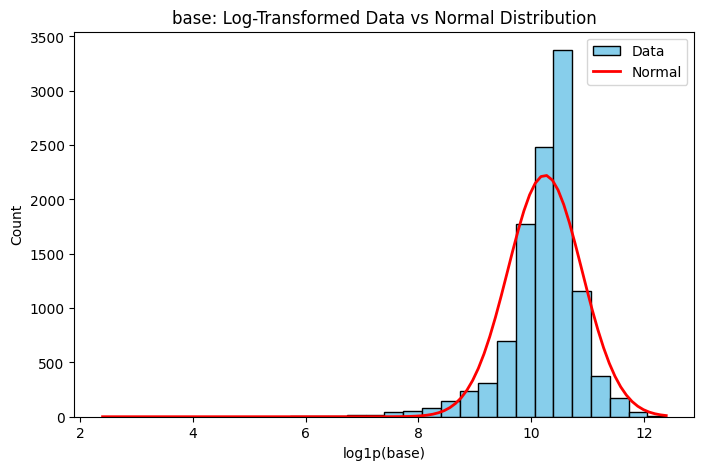

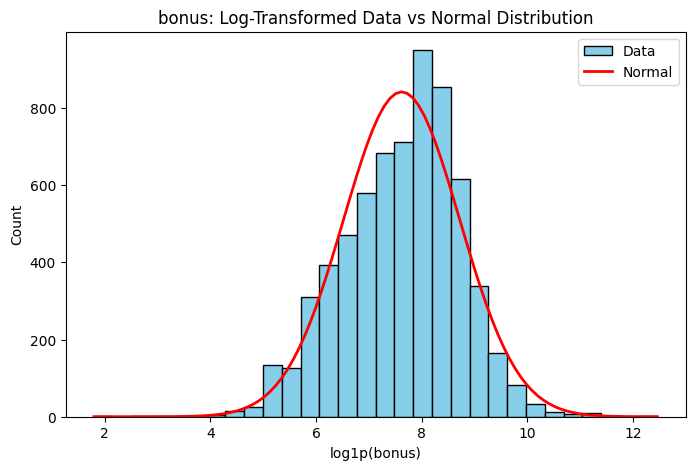

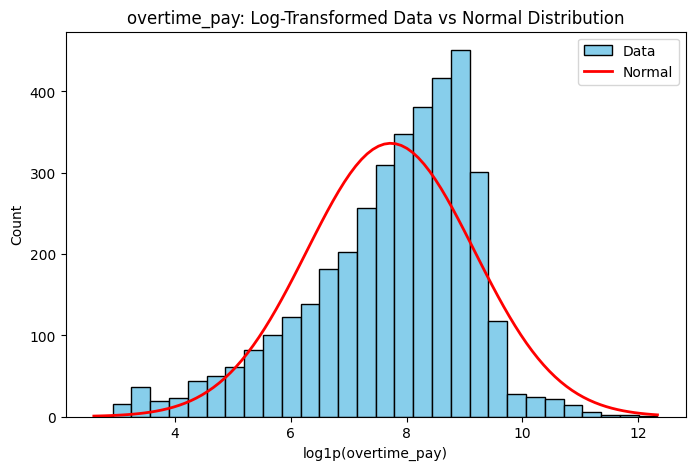

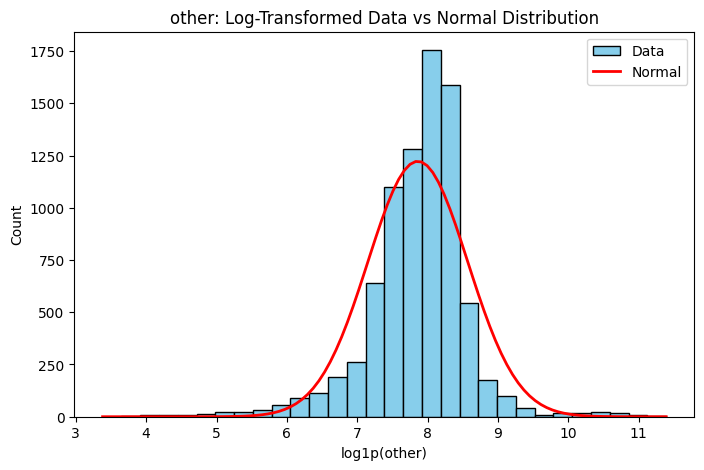

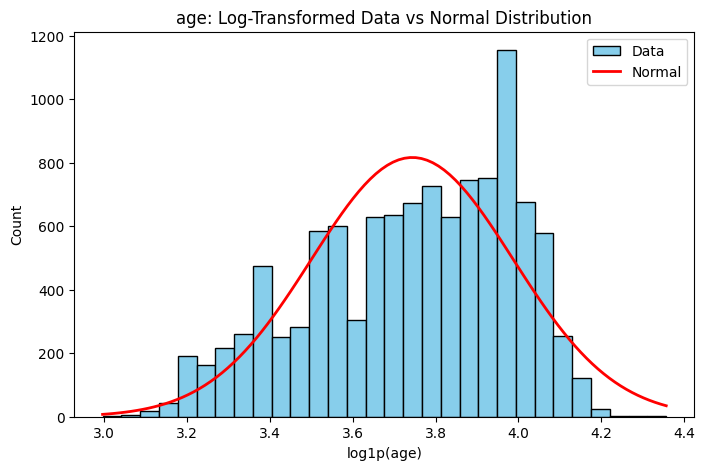

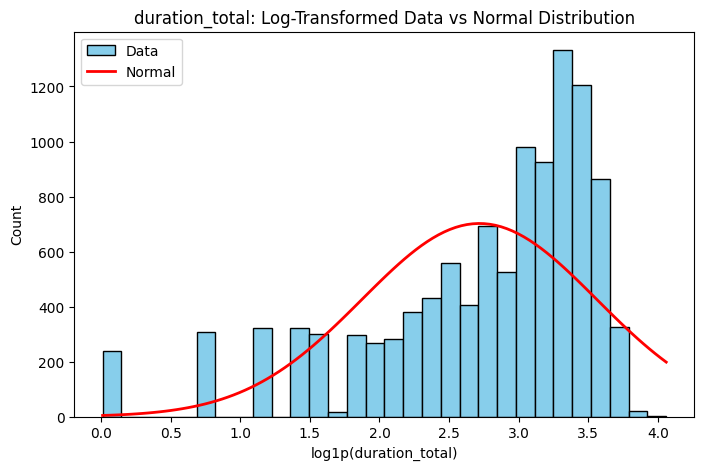

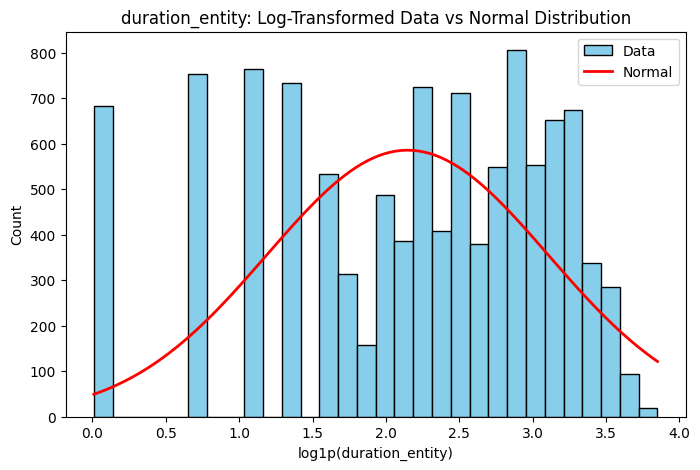

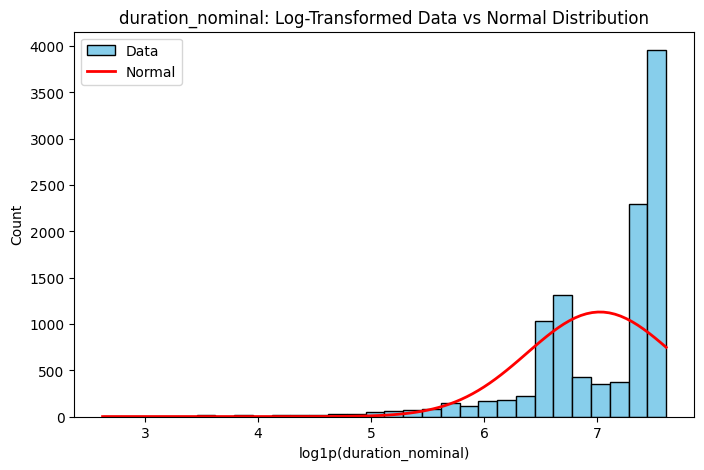

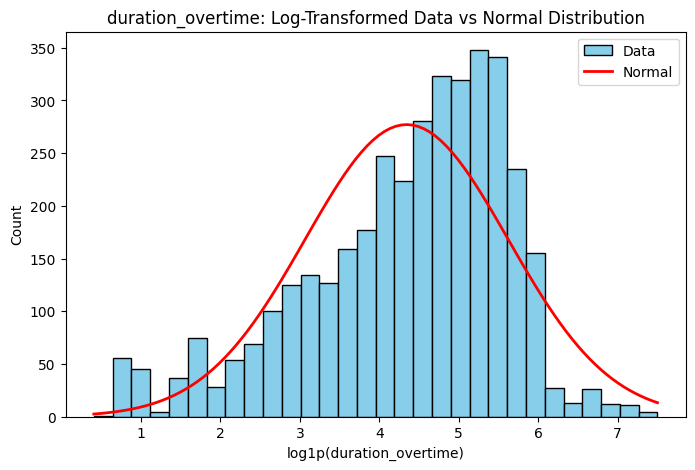

In [ ]:
for col in numerical_columns:
  plt.figure(figsize=(8, 5))
  filtered = data[col][data[col] > 0].apply(np.log1p)

  counts, bins, _ = plt.hist(filtered, bins=30, label='Data')
  bin_width = bins[1] - bins[0]
  x = np.linspace(filtered.min(), filtered.max(), 100)

  normal_pdf = norm.pdf(x, np.mean(filtered), np.std(filtered))
  normal_scaled = normal_pdf * len(filtered) * bin_width
  plt.plot(x, normal_scaled, 'r-', lw=2, label='Normal')

  plt.title(f'{col}: Log-Transformed Data vs Normal Distribution')
  plt.xlabel(f'log1p({col})')
  plt.ylabel('Count')
  plt.legend()
  plt.show()

* Base salary and age follow a normal distribution.

* Bonus, overtime pay, duration of overtime, and other approximate a normal distribution after excluding zero values and applying a log(1 + x) transformation. However, a substantial portion of observations for these variables are zero.

* Duration entity follows an exponential distribution.

* Duration nominal appears to be a mixture of two normal distributions, which likely reflects differences in work arrangements—such as some individuals working part-time.

## Task 2. Clustering

I try to perform clustering on all variables

### KPrototypes

Initially, I experimented with the K-Prototypes algorithm, as it is specifically designed for mixed data types - both categorical and numerical. However, due to its computational intensity, I applied it only to a subset of 1000 observations. One advantage of K-Prototypes is that it does not require one-hot encoding, which simplifies preprocessing. Nevertheless, it still requires scaling of numerical features, which I handled using StandardScaler.

For evaluating clustering quality, I used silhouette scores with Gower distance as the metric, since Gower distance is well-suited for mixed-type data.

For k=2, silhouette score is 0.167277991771698
For k=3, silhouette score is 0.08746064454317093
For k=4, silhouette score is 0.1180824562907219
For k=5, silhouette score is 0.13591650128364563
For k=6, silhouette score is 0.11082133650779724
For k=7, silhouette score is 0.08403628319501877
For k=8, silhouette score is 0.08872885257005692
For k=9, silhouette score is 0.0818830356001854
For k=10, silhouette score is 0.07390955835580826


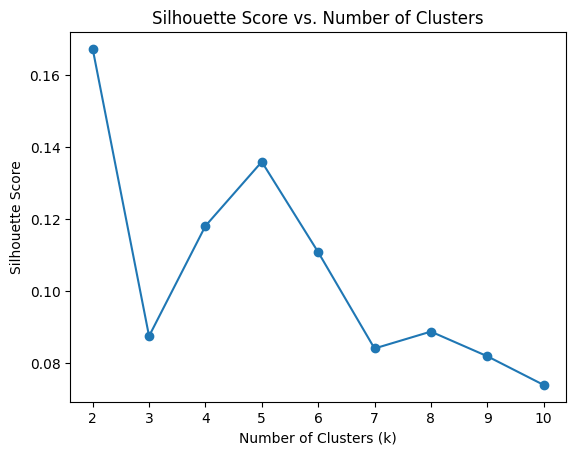

The best number of clusters is 2
For k=2, silhouette score is 0.1691405177116394


In [ ]:
scaled_data = data.copy()
scaler = StandardScaler()
scaled_data[numerical_columns] = pd.DataFrame(scaler.fit_transform(data[numerical_columns]))

categorical_columns_indices = [scaled_data.columns.get_loc(col) for col in categorical_columns]
categorical_columns_indices

subset = scaled_data.sample(n=1000, random_state=42)
subset_matrix = subset.to_numpy()
gower_dist = gower.gower_matrix(subset)

silhouette_scores = []

for k in range(2, 11):
  kproto = KPrototypes(n_clusters=k, init='Huang', n_init=3 , verbose=0, random_state=42, max_iter=20)
  clusters = kproto.fit_predict(subset_matrix, categorical=categorical_columns_indices)
  silhouette = silhouette_score(gower_dist, clusters, metric='precomputed')
  silhouette_scores.append(silhouette)
  print(f"For k={k}, silhouette score is {silhouette}")

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.show()
best_k = np.argmax(silhouette_scores) + 2
print(f"The best number of clusters is {best_k}")


# Calculating on whole dataset (will be very slow)
matrix = scaled_data.to_numpy()
gower_dist = gower.gower_matrix(scaled_data)

kproto = KPrototypes(n_clusters=best_k, init='Huang', n_init=3 , verbose=0, random_state=42)
clusters = kproto.fit_predict(matrix, categorical=categorical_columns_indices)
silhouette = silhouette_score(gower_dist, clusters, metric='precomputed')
print(f"For k={best_k}, silhouette score is {silhouette}")


### K-Means

To apply K-Means clustering, I first preprocessed the data by sacaling numerical features using StandardScaler, ensuring they had zero mean and unit variance. Categorical variables were then converted to numerical format using one-hot encoding, with the first category dropped to avoid multicollinearity.

For k=2, silhouette score is 0.20546842797658882
For k=3, silhouette score is 0.21180701949762631
For k=4, silhouette score is 0.22624682227300222
For k=5, silhouette score is 0.19945274207791136
For k=6, silhouette score is 0.20468995933164594
For k=7, silhouette score is 0.2074051387788929
For k=8, silhouette score is 0.20006750958368677
For k=9, silhouette score is 0.20508583080767576
For k=10, silhouette score is 0.20518263685415492


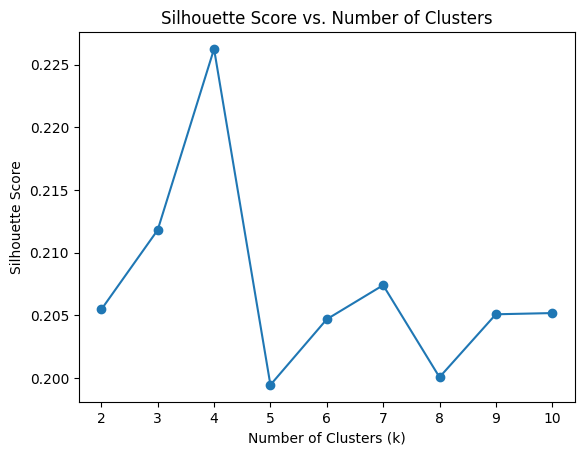

In [ ]:
preprocessed_data = data.copy()
scaler = StandardScaler()
preprocessed_data[numerical_columns] = pd.DataFrame(scaler.fit_transform(data[numerical_columns]))
preprocessed_data = pd.get_dummies(preprocessed_data, columns=categorical_columns, drop_first=True)

silhouette_scores = []
for k in range(2, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  clusters = kmeans.fit_predict(preprocessed_data)
  silhouette = silhouette_score(preprocessed_data, clusters)
  silhouette_scores.append(silhouette)
  print(f"For k={k}, silhouette score is {silhouette}")

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.show()

We get a little bit better silhouette scores, but still pretty bad

### Agglomerative Clustering

For k=2, silhouette score is 0.9221380865849538
For k=3, silhouette score is 0.8765578372998455
For k=4, silhouette score is 0.815920193846666
For k=5, silhouette score is 0.6818596869963048
For k=6, silhouette score is 0.6820575178108532
For k=7, silhouette score is 0.6819628975183272
For k=8, silhouette score is 0.5871476086596908
For k=9, silhouette score is 0.3938589099940691
For k=10, silhouette score is 0.39332119064712656


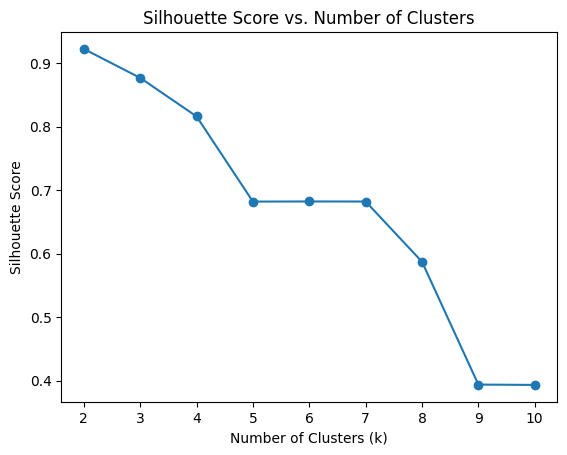

The best number of clusters is 2


In [ ]:
preprocessed_data = data.copy()
scaler = StandardScaler()
preprocessed_data[numerical_columns] = pd.DataFrame(scaler.fit_transform(data[numerical_columns]))
preprocessed_data = pd.get_dummies(preprocessed_data, columns=categorical_columns, drop_first=True)

silhouette_scores = []
for k in range(2, 11):
  clusterer = AgglomerativeClustering(n_clusters=k, linkage='complete', metric='euclidean')
  labels = clusterer.fit_predict(preprocessed_data)
  silhouette = silhouette_score(preprocessed_data, labels)
  silhouette_scores.append(silhouette)
  print(f"For k={k}, silhouette score is {silhouette}")

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.show()
best_k = np.argmax(silhouette_scores) + 2
print(f"The best number of clusters is {best_k}")

In [ ]:
clusterer = AgglomerativeClustering(n_clusters=best_k, linkage='complete', metric='euclidean')
labels = clusterer.fit_predict(preprocessed_data)

unique_labels, counts = np.unique(labels, return_counts=True)
label_counts = dict(zip(unique_labels, counts))
print(label_counts)

{np.int64(0): np.int64(10999), np.int64(1): np.int64(1)}


Although this method provides the best silhouette score (0.92), the clustering results are terrible, as one cluster contains nearly all of the observations

## Task 3. Classification

### Logistic Regression

I decided to start with Logistic Regression, as it is the simplest method.

Cross-validated accuracy scores: [0.87954545 0.87272727 0.84715909 0.86477273 0.87443182]
Average accuracy: 0.8677272727272728
Accuracy on unseen data: 0.8640909090909091
Confusion Matrix on unseen data:
 [[ 599  148]
 [ 151 1302]]
Classification Report on unseen data:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80       747
           1       0.90      0.90      0.90      1453

    accuracy                           0.86      2200
   macro avg       0.85      0.85      0.85      2200
weighted avg       0.86      0.86      0.86      2200



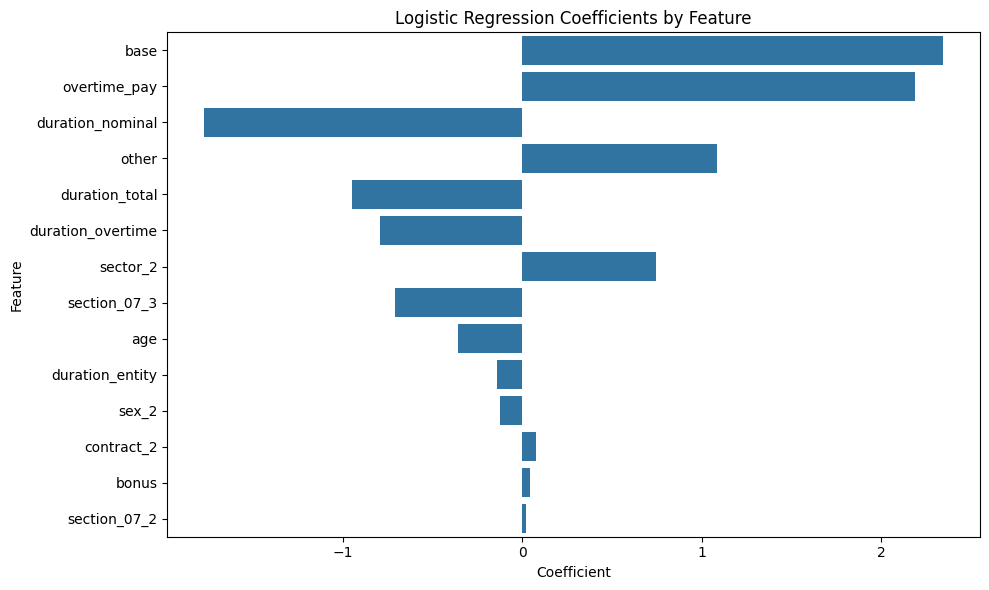

In [ ]:
X = data.drop(columns = ["education"])
y = data['education'].apply(lambda x: 1 if int(x) <= 2 else 0)
X = pd.get_dummies(X, columns=[col for col in categorical_columns if col != 'education'], drop_first=True)
scaler = StandardScaler()
X[numerical_columns] = pd.DataFrame(scaler.fit_transform(X[numerical_columns]))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000, random_state=42)

scores = cross_val_score(model, X_train, y_train, cv=5)
print("Cross-validated accuracy scores:", scores)
print("Average accuracy:", scores.mean())

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy on unseen data:", accuracy_score(y_test, y_pred))
print("Confusion Matrix on unseen data:\n", confusion_matrix(y_test, y_pred))
print("Classification Report on unseen data:\n", classification_report(y_test, y_pred))

feature_names = X.columns
coefs = model.coef_[0]

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df,
    x='Coefficient',
    y='Feature',
)
plt.title('Logistic Regression Coefficients by Feature')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# coef_df[['Feature', 'Coefficient']]


Model performed very well (Accuracy on unseen data was 0.86). It turns out that base salary and overtime pay is positively corelated with higer education while duration nominal is negatively corelated.

### Random Forest

I also tried using Random Forest Classifier

Cross-validated accuracy scores: [0.89431818 0.88693182 0.875      0.89090909 0.88465909]
Average accuracy: 0.8863636363636364
Accuracy: 0.8786363636363637
Confusion Matrix:
 [[ 625  122]
 [ 145 1308]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.82       747
           1       0.91      0.90      0.91      1453

    accuracy                           0.88      2200
   macro avg       0.86      0.87      0.87      2200
weighted avg       0.88      0.88      0.88      2200



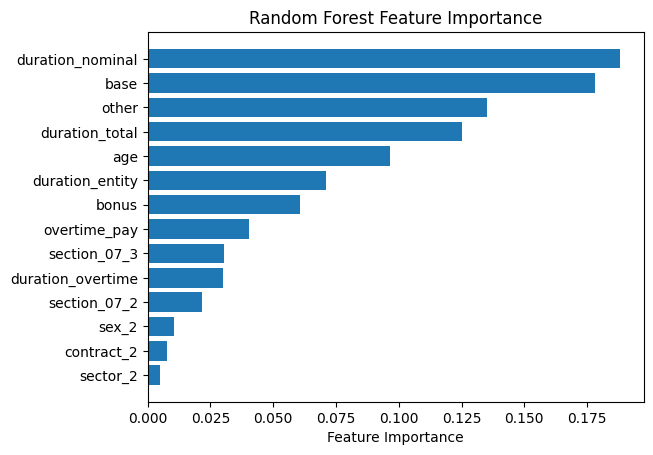

In [ ]:
X = data.drop(columns = ["education"])
y = data['education'].apply(lambda x: 1 if int(x) <= 2 else 0)
X = pd.get_dummies(X, columns=[col for col in categorical_columns if col != 'education'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

scores = cross_val_score(rf_model, X_train, y_train, cv=5)
print("Cross-validated accuracy scores:", scores)
print("Average accuracy:", scores.mean())

y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

importances = rf_model.feature_importances_
features = X.columns
sorted_idx = importances.argsort()
plt.barh(range(len(sorted_idx)), importances[sorted_idx])
plt.yticks(range(len(sorted_idx)), [features[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

While the accuracy of this model is similar to that of the Logistic Regression model, it highlights different features as more important. Specifically, duration nominal and other have emerged as significant predictors.

## Task 4. Regression

### Linear regression

Firstly, I applied linear regression using all available variables, with numerical features scaled and categorical features one-hot encoded. I also added const variable, because sm.OLS doesn't do it under the hood

In [ ]:
X = data.drop(columns=['base'])
y = data['base']
X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)
scaler = StandardScaler()
numerical_columns_to_scale = [col for col in numerical_columns if col != 'base']
X = sm.add_constant(X)
X = X.astype(float)
X[numerical_columns_to_scale] = pd.DataFrame(scaler.fit_transform(X[numerical_columns_to_scale]))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ols_model = sm.OLS(y_train, X_train).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   base   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     501.6
Date:                Mon, 05 May 2025   Prob (F-statistic):               0.00
Time:                        21:31:49   Log-Likelihood:                -96204.
No. Observations:                8800   AIC:                         1.924e+05
Df Residuals:                    8781   BIC:                         1.926e+05
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              5.035e+04    925.314     54.415      0.000    4.85e+04    5.22e+04
bonus              1738.4753    143.099     12.149      0.000    1457.967    2018.983
overtime_pay       1317.2529    271.157      4.858      0.000     785.722    1848.784
other              3713.5842    169.810     21.869      0.000    3380.717    4046.451
age                2620.4673    311.112      8.423      0.000    2010.615    3230.319
duration_total     1736.3541    348.219      4.986      0.000    1053.764    2418.944
duration_entity    1751.4663    201.242      8.703      0.000    1356.984    2145.949
duration_nominal   5798.2932    206.712     28.050      0.000    5393.090    6203.497
duration_overtime  1396.5108    292.633      4.772      0.000     822.882    1970.140
sector_2            -91.9402    753.390     -0.122      0.903   -1568.761    1384.880
section_07_2      -7162.2366    455.788    -15.714      0.000   -8055.688   -6268.785
section_07_3       -879.1450    469.039     -1.874      0.061   -1798.571      40.281
sex_2             -1689.0518    346.716     -4.872      0.000   -2368.697   -1009.407
education_2       -4359.5638    837.962     -5.203      0.000   -6002.166   -2716.962
education_3       -1.772e+04   1037.269    -17.085      0.000   -1.98e+04   -1.57e+04
education_4       -2.098e+04    913.664    -22.958      0.000   -2.28e+04   -1.92e+04
education_5       -2.833e+04    981.941    -28.849      0.000   -3.03e+04   -2.64e+04
education_6       -2.953e+04   1151.923    -25.636      0.000   -3.18e+04   -2.73e+04
contract_2        -5550.3517    455.170    -12.194      0.000   -6442.591   -4658.112
==============================================================================
Omnibus:                     4341.282   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            93724.988
Skew:                           1.875   Prob(JB):                         0.00
Kurtosis:                      18.542   Cond. No.                         23.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
y_pred = ols_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2 Score: {r2:.3f}")
print(f"RMSE: {rmse:.2f}")

R^2 Score: 0.481
RMSE: 13868.68


I calculate correlation matrix to find variables that I can remove to simplify the model:

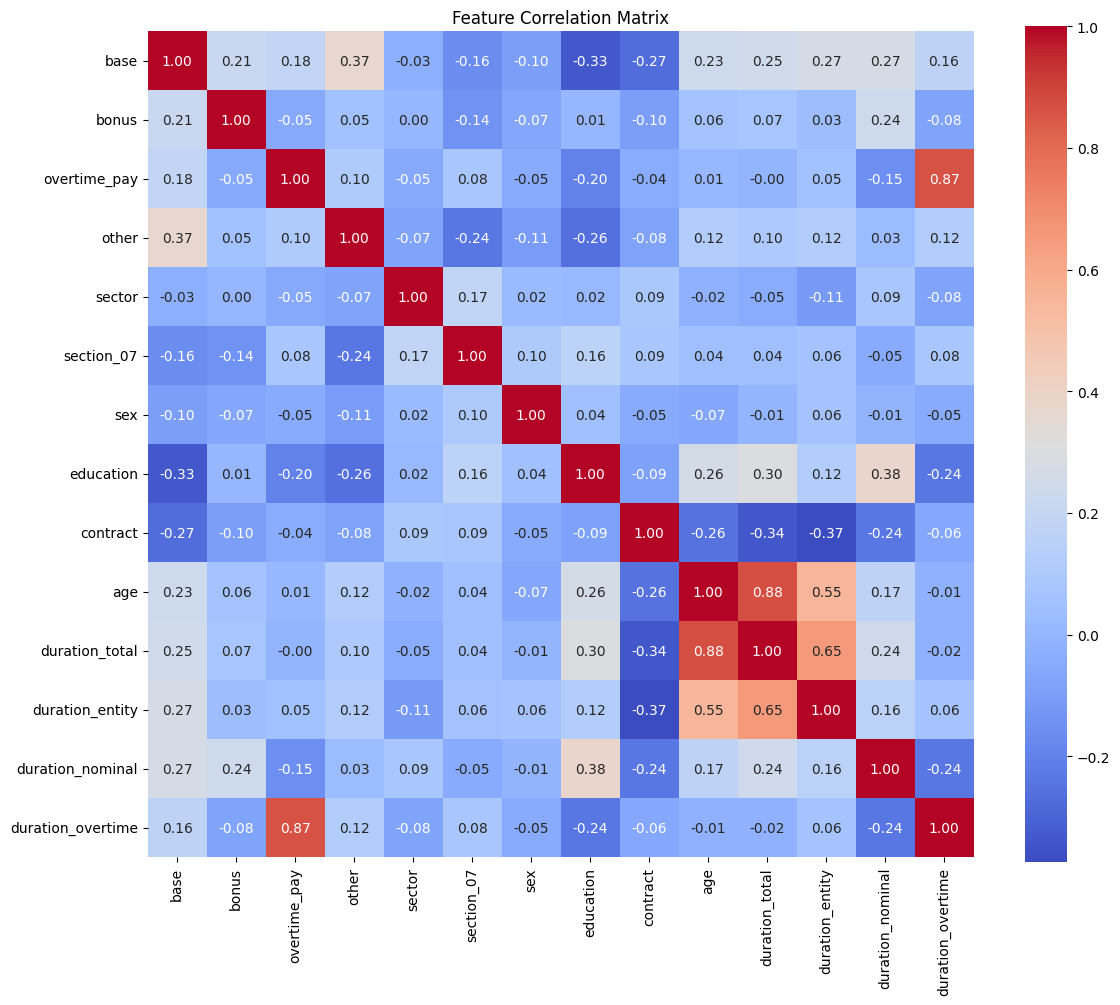

In [ ]:
corr_matrix = data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

I removed variables with p-values greater than 0.05 to ensure that all included features are statistically significant. I also remove variables that have high corelation.

R^2 Score: 0.475
RMSE: 13944.48


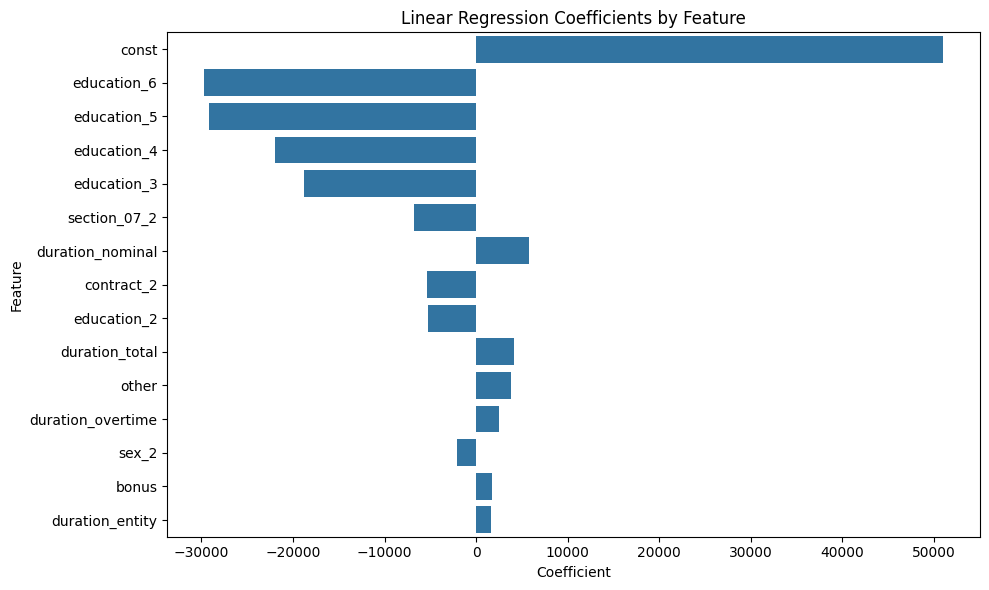

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   base   R-squared:                       0.501
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     630.9
Date:                Mon, 05 May 2025   Prob (F-statistic):               0.00
Time:                        21:31:53   Log-Likelihood:                -96254.
No. Observations:                8800   AIC:                         1.925e+05
Df Residuals:                    8785   BIC:                         1.926e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              5.101e+04    869.373     58.671      0.000    4.93e+04    5.27e+04
bonus              1776.5310    143.192     12.407      0.000    1495.842    2057.220
other              3831.9293    166.846     22.967      0.000    3504.871    4158.987
duration_total     4129.8267    207.454     19.907      0.000    3723.168    4536.485
duration_entity    1644.2635    200.363      8.206      0.000    1251.505    2037.022
duration_nominal   5743.3899    204.882     28.033      0.000    5341.774    6145.006
duration_overtime  2520.9919    158.523     15.903      0.000    2210.249    2831.735
section_07_2      -6743.5733    373.353    -18.062      0.000   -7475.433   -6011.714
sex_2             -2044.6513    345.613     -5.916      0.000   -2722.134   -1367.169
education_2       -5253.4115    825.780     -6.362      0.000   -6872.133   -3634.690
education_3       -1.875e+04   1035.827    -18.104      0.000   -2.08e+04   -1.67e+04
education_4       -2.198e+04    908.608    -24.186      0.000   -2.38e+04   -2.02e+04
education_5       -2.918e+04    978.948    -29.808      0.000   -3.11e+04   -2.73e+04
education_6        -2.97e+04   1153.979    -25.735      0.000    -3.2e+04   -2.74e+04
contract_2        -5366.4282    455.026    -11.794      0.000   -6258.385   -4474.471
==============================================================================
Omnibus:                     4390.175   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            93708.017
Skew:                           1.908   Prob(JB):                         0.00
Kurtosis:                      18.524   Cond. No.                         22.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
X_significant = X.drop(columns=['sector_2', 'section_07_3', 'age', 'overtime_pay'])
X_significant_train, X_significant_test, y_significant_train, y_significant_test = train_test_split(X_significant, y, test_size=0.2, random_state=42)
ols_model_significant = sm.OLS(y_significant_train, X_significant_train).fit()
y_pred = ols_model_significant.predict(X_significant_test)

r2 = r2_score(y_significant_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_significant_test, y_pred))

print(f"R^2 Score: {r2:.3f}")
print(f"RMSE: {rmse:.2f}")

coef_df = pd.DataFrame({'Feature': X_significant.columns, 'Coefficient': ols_model_significant.params})
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(
  data=coef_df,
  x='Coefficient',
  y='Feature',
)
plt.title('Linear Regression Coefficients by Feature')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

ols_model_significant.summary()


Unfortunately, removing variables with high p-values did not improve the model's performance. However, it did make the model more robust and simpler.

* Variables that have positive effect: bonus, overtime_pay, other, age, duration_total, duration_entity, duration_nominal, duration_overtime
* Variables that have negative effect: section_07_2, sex_2, education_2, education_3, education_4, education_5, education_6, contract_2

The results suggest that individuals with a PhD are not negatively impacted in terms of compensation, as the education_x variables for x > 1 have a negative effect. In contrast, individuals with lower levels of education face progressively greater reductions in compensation, with the lower the education level, the more significant the penalty.

Naturally, variables closely related to base salary, such as bonuses and overtime pay, exhibit a positive correlation with base salary.

### Random Forest

I also tried using Random Forest Regressor

R^2: 0.8181772089516061
RMSE: 8209.430958634204


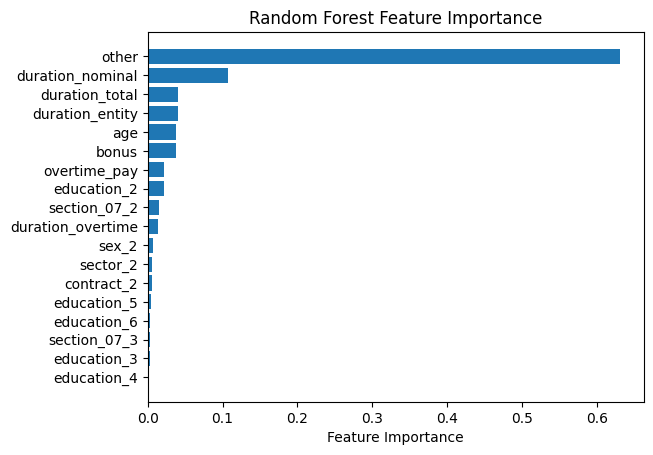

In [ ]:
X = data.drop(columns=['base'])
y = data['base']
X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("R^2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

importances = model.feature_importances_
features = X.columns
sorted_idx = importances.argsort()
plt.barh(range(len(sorted_idx)), importances[sorted_idx])
plt.yticks(range(len(sorted_idx)), [features[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

This model performs better than the linear one. Let's remove features that are not important.

In [ ]:
importances = model.feature_importances_
features = X.columns
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=False)
threshold = 0.01
important_features = feat_imp[feat_imp['Importance'] > threshold]['Feature'].tolist()
X_reduced = X[important_features]
print(X_reduced.columns)

X_reduced_train, X_reduced_test, y_reduced_train, y_reduced_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
model_reduced = RandomForestRegressor(n_estimators=100, random_state=42)
model_reduced.fit(X_reduced_train, y_reduced_train)

y_pred_reduced = model_reduced.predict(X_reduced_test)
print("R^2:", r2_score(y_reduced_test, y_pred_reduced))
print("RMSE:", np.sqrt(mean_squared_error(y_reduced_test, y_pred_reduced)))

Index(['other', 'duration_nominal', 'duration_total', 'duration_entity', 'age',
       'bonus', 'overtime_pay', 'education_2', 'section_07_2',
       'duration_overtime'],
      dtype='object')
R^2: 0.7979024838200459
RMSE: 8655.046046594505


And again it didn't improve the model.

Interestingly, this model identifies a completely different set of features as important compared to the linear regression model.